# BSRN Quality Control Demo
# BSRN 质量控制演示

This notebook demonstrates the core functionality of the `bsrn` package, including data reading, clear-sky modeling, and quality control tests.
本笔记本演示了 `bsrn` 包的核心功能，包括数据读取、晴空建模和质量控制测试。

## 1. Import Libraries
## 1. 导入库

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add src directory to path so we can import the local bsrn package
# 将 src 目录添加到路径，以便我们可以导入本地 bsrn 包
sys.path.insert(0, os.path.abspath("../src"))
import bsrn

# Set display options
pd.options.display.max_columns = None
%matplotlib inline

## 2. Load Sample Data
## 2. 加载示例数据

In [2]:
# Adjust path to find the data folder from the notebooks directory
stn = "QIQ"
file_path = "../data/QIQ/qiq0624.dat.gz"
if os.path.exists(file_path):
    df = bsrn.io.readers.read_bsrn_station_to_archive(file_path)
    print(f"Data for {stn} loaded successfully.")
    display(df.head())
else:
    print(f"File not found: {file_path}. Current working directory: {os.getcwd()}")

Data for QIQ loaded successfully.


,ghi,bni,dhi,lwd,temp,rh,pressure
time,,,,,,,
2024-06-01 00:00:00+00:00,317.0,4.0,315.0,361.0,23.6,35.0,990.0
2024-06-01 00:01:00+00:00,318.0,4.0,316.0,362.0,23.6,35.0,990.0
2024-06-01 00:02:00+00:00,318.0,2.0,318.0,361.0,23.6,35.0,990.0
2024-06-01 00:03:00+00:00,320.0,2.0,320.0,361.0,23.7,35.0,990.0
2024-06-01 00:04:00+00:00,321.0,2.0,322.0,361.0,23.8,35.0,990.0


## 3. Clear-Sky Modeling
## 3. 晴空建模

In [3]:
# Add clear-sky GHI, BNI, and DHI columns using Ineichen model
if 'df' in locals():
    df = bsrn.physics.clearsky.add_clearsky_columns(df, stn)
    display(df[["ghi", "ghi_clear", "bni", "bni_clear"]].head())

,ghi,ghi_clear,bni,bni_clear
time,,,,
2024-06-01 00:00:00+00:00,317.0,577.049927,4.0,734.836049
2024-06-01 00:01:00+00:00,318.0,579.555460,4.0,735.860264
2024-06-01 00:02:00+00:00,318.0,582.053714,2.0,736.875703
2024-06-01 00:03:00+00:00,320.0,584.544633,2.0,737.882442
2024-06-01 00:04:00+00:00,321.0,587.028162,2.0,738.880559


## 4. Quality Control Tests
## 4. 质量控制测试

We apply Level 1 (Physically Possible), Level 2 (Extremely Rare), and Level 3 (Comparison) tests.
我们应用一级（物理可能）、二级（极罕见）和三级（比较）测试。

In [4]:
if 'df' in locals():
    # Level 1: Physically Possible Limits
    df = bsrn.qc.ppl.test_physically_possible(df, station_code=stn)
    
    # Level 2: Extremely Rare Limits
    df = bsrn.qc.erl.test_extremely_rare(df, station_code=stn)
    
    # Level 3: Closure (Comparison) Tests
    df = bsrn.qc.closure.test_closure(df, station_code=stn)
    
    # Tracker Status Detection
    df = bsrn.qc.tracker.test_tracker_off(df, station_code=stn)
    
    print("QC tests completed.")
    # Summary of flags
    flag_cols = [c for c in df.columns if c.startswith('f_')]
    print("Flag counts (non-zero indicates failure):")
    # Note: flag=0 means fail in our current implementation for PPL/ERL/Closure 
    # but for tracker 1 means fail. Standardizing to 0=Pass, 1=Fail below:
    for col in ['f_ppl_ghi', 'f_ppl_bni', 'f_ppl_dhi', 'f_ppl_lwd', 'f_erl_ghi', 'f_erl_bni', 'f_erl_dhi', 'f_erl_lwd', 'f_closure']:
        df[col] = 1 - df[col]
        
    display(df[flag_cols].sum())

QC tests completed.
Flag counts (non-zero indicates failure):


f_ppl_ghi        1139
f_ppl_bni        1140
f_ppl_dhi        1139
f_ppl_lwd        1139
f_erl_ghi        4048
f_erl_bni        1157
f_erl_dhi        8182
f_erl_lwd        1139
f_closure           3
f_tracker_off     494
dtype: int64

## 5. Visualization
## 5. 可视化

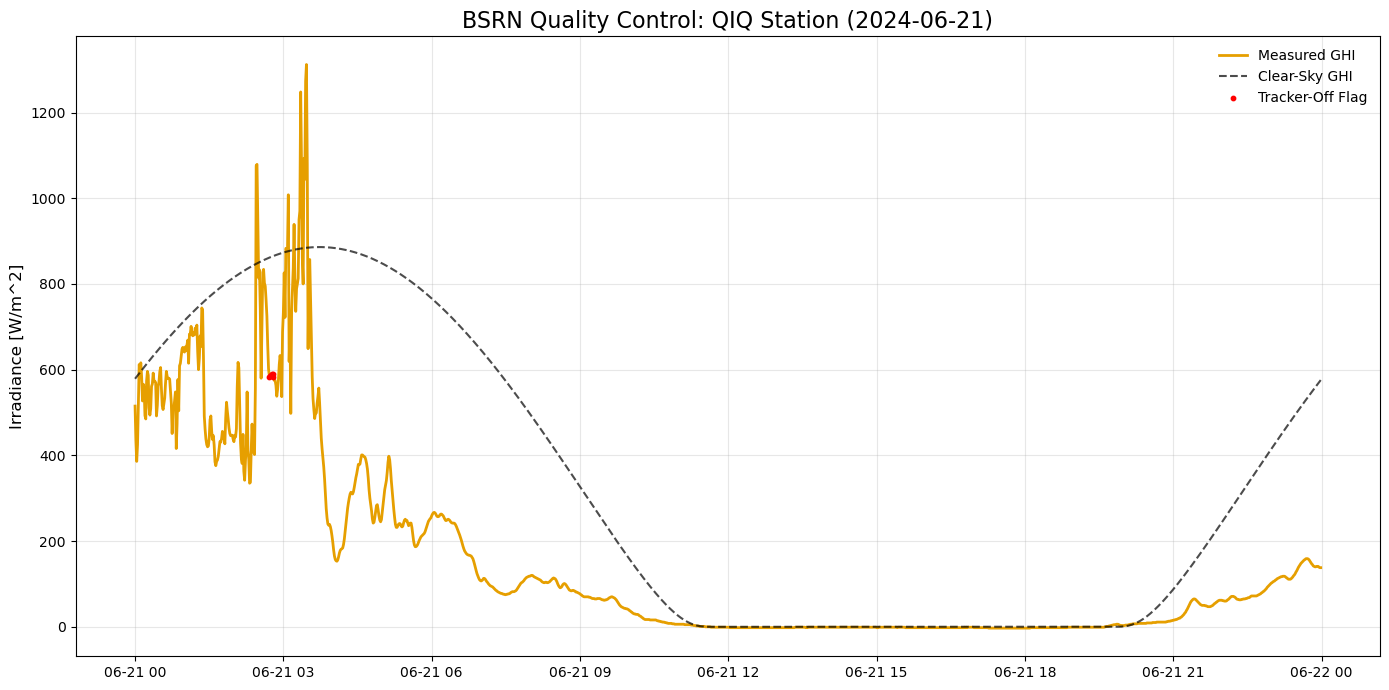

In [5]:
if 'df' in locals():
    # Select a clear day to visualize (June 21, 2024)
    # 选择一个晴天进行可视化 (2024年6月21日)
    day_data = df.loc["2024-06-21"]
    
    plt.figure(figsize=(14, 7))
    plt.plot(day_data.index, day_data['ghi'], label='Measured GHI', color='#E69F00', linewidth=2)
    plt.plot(day_data.index, day_data['ghi_clear'], label='Clear-Sky GHI', color='#000000', linestyle='--', alpha=0.7)
    
    # Highlight errors (e.g., if tracker was off)
    if 'f_tracker_off' in day_data.columns:
        tracker_off = day_data[day_data['f_tracker_off'] > 0]
        if not tracker_off.empty:
            plt.scatter(tracker_off.index, tracker_off['ghi'], color='red', label='Tracker-Off Flag', s=10, zorder=5)
            
    plt.title("BSRN Quality Control: QIQ Station (2024-06-21)", fontsize=16)
    plt.ylabel("Irradiance [W/m^2]", fontsize=12)
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()